# Step by Step Analysis of the cohort Data

In [1]:
# Import dependencies and Base Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from report_pdf import make_pdf
from datetime import datetime
from pathlib import Path
from zipfile import BadZipFile

# ===============================
# 📁 CONFIG
# ===============================
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().resolve()
OUTPUT_FILE = str(BASE_DIR / "어린이코호트_자동분석리포트.xlsx")
LOG_FILE = str(BASE_DIR / "analysis_chat_log.xlsx")
LOG_SHEET = "ChatLog"


In [2]:
# Read the Work book if file is xls convert it to xlsx file
def _read_workbook_file(path: Path) -> pd.ExcelFile:
    engine = "xlrd" if path.suffix.lower() == ".xls" else "openpyxl"
    return pd.ExcelFile(path, engine=engine)


def _convert_xls_to_xlsx(xls_path: Path) -> Path:
    xlsx_path = xls_path.with_suffix(".xlsx")

    if xlsx_path.exists() and xlsx_path.stat().st_mtime >= xls_path.stat().st_mtime:
        return xlsx_path

    xls_file = pd.ExcelFile(xls_path, engine="xlrd")
    with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="w") as writer:
        for sheet_name in xls_file.sheet_names:
            df = pd.read_excel(xls_path, sheet_name=sheet_name, engine="xlrd")
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    return xlsx_path

In [3]:
# prepare input file

def _prepare_input_file() -> Path:
    # Prefer existing .xlsx workbooks; otherwise convert the first valid .xls workbook.
    candidates = [
        BASE_DIR / "어린이코호트 임상데이터.xlsx",
        BASE_DIR / "어린이코호트 임상데이터.xls",
        BASE_DIR / "어린이코호트 임상데이터_수정0518.xlsx",
        BASE_DIR / "어린이코호트 임상데이터_수정0518.xls",
    ]

    last_error: Exception | None = None
    for path in candidates:
        if not path.exists():
            continue

        if path.suffix.lower() == ".xlsx":
            try:
                _read_workbook_file(path)
                return path
            except BadZipFile as exc:
                last_error = exc
                continue

        try:
            return _convert_xls_to_xlsx(path)
        except Exception as exc:
            last_error = exc

    found_excel = sorted([p.name for p in BASE_DIR.glob("*.xls*")])
    raise FileNotFoundError(
        "No usable input workbook found. Expected one of: "
        f"{[p.name for p in candidates]}. Found Excel files: {found_excel}. "
        f"Last error: {last_error}"
    )


INPUT_FILE = _prepare_input_file()


In [4]:
# ==Added Reference Ranges=============================
# Reference ranges (from your workbook Sheet12 / REF_6_10_M style table)
REF = {
    "TSH":      {"low": 0.6, "high": 4.8, "type": "range"},
    "Free T4":  {"low": 0.9, "high": 1.67, "type": "range"},
    "HbA1c":    {"low": 4.0, "high": 6.0, "type": "range"},
    "FSH":      {"low": 0.1, "high": 2.3, "type": "range"},
    # 3-stage rules mentioned in your reference sheet:
    "T.Cholestero": {"cut1": 170, "cut2": 199, "type": "3stage"},  # normal / borderline / high
    "Glu-FBS(S)":   {"cut1": 70,  "cut2": 99,  "type": "3stage"}   # normal / preDM / DM-suspect (labeling will be yours)
}

def flag_range(series, low, high):
    return np.where(series < low, "LOW",
           np.where(series > high, "HIGH", "NORMAL"))

def flag_3stage(series, cut1, cut2, labels=("NORMAL","BORDERLINE","HIGH")):
    # <=cut1: NORMAL, cut1~cut2: BORDERLINE, >cut2: HIGH
    return np.where(series <= cut1, labels[0],
           np.where(series <= cut2, labels[1], labels[2]))

def build_flags(df):
    out = df.copy()
    for col, rule in REF.items():
        if col not in out.columns:
            continue

        # Normalize mixed/object lab values to numeric so reference comparisons are safe.
        series_num = pd.to_numeric(out[col], errors="coerce")

        if rule["type"] == "range":
            out[col + "_flag"] = np.where(
                series_num.isna(),
                "MISSING_OR_INVALID",
                flag_range(series_num, rule["low"], rule["high"]),
            )
        elif rule["type"] == "3stage":
            # You can customize labels for FBS: ("NORMAL","PREDIABETES","DIABETES_SUSPECT")
            if col == "Glu-FBS(S)":
                out[col + "_flag"] = np.where(
                    series_num.isna(),
                    "MISSING_OR_INVALID",
                    flag_3stage(
                        series_num,
                        rule["cut1"],
                        rule["cut2"],
                        labels=("NORMAL", "PREDIABETES", "DIABETES_SUSPECT"),
                    ),
                )
            else:
                out[col + "_flag"] = np.where(
                    series_num.isna(),
                    "MISSING_OR_INVALID",
                    flag_3stage(series_num, rule["cut1"], rule["cut2"]),
                )
    return out


In [5]:
# ===============================
# ✅ CHAT LOG FUNCTION
# ===============================
def log_chat(message, speaker):
    new_entry = pd.DataFrame([[
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        speaker,
        message
    ]], columns=["Timestamp", "Speaker", "Message"])

    log_path = Path(LOG_FILE)

    try:
        old_log = pd.read_excel(log_path, sheet_name=LOG_SHEET, engine='openpyxl')
        updated_log = pd.concat([old_log, new_entry], ignore_index=True)
    except Exception:
        updated_log = new_entry

    if log_path.exists():
        with pd.ExcelWriter(log_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            updated_log.to_excel(writer, sheet_name=LOG_SHEET, index=False)
    else:
        with pd.ExcelWriter(log_path, engine='openpyxl', mode='w') as writer:
            updated_log.to_excel(writer, sheet_name=LOG_SHEET, index=False)

# ===============================
# ✅ DATA LOAD
# ===============================
def load_data():
    log_chat("Load data from Excel", "Copilot")

    try:
        df = pd.read_excel(INPUT_FILE, sheet_name=0, engine="openpyxl")
    except BadZipFile as exc:
        raise ValueError(
            f"{INPUT_FILE} is not a valid .xlsx workbook. "
            "The loader should have converted a .xls file first; please check the source workbook."
        ) from exc

    return df

In [6]:
# ===============================
# ✅ BASIC ANALYSIS
# ===============================
def basic_analysis(df):
    log_chat("Run basic statistics (describe)", "Copilot")
    
    num_df = df.select_dtypes(include=['number'])

    # Stats
    desc = num_df.describe()

    # Correlation
    corr = num_df.corr()

    return desc, corr, num_df

# ===============================
# ✅ OUTLIER DETECTION
# ===============================
def detect_outliers(num_df):
    log_chat("Detect outliers (IQR)", "Copilot")

    outlier_summary = {}
    for col in num_df.columns:
        Q1 = num_df[col].quantile(0.25)
        Q3 = num_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = num_df[(num_df[col] < lower) | (num_df[col] > upper)][col]
        outlier_summary[col] = len(outliers)

    outlier_df = pd.DataFrame(list(outlier_summary.items()),
                              columns=['Column', 'Outlier_Count'])

    return outlier_df


In [7]:
# ===============================
# ✅ VISUALIZATION
# ===============================
def generate_plots(num_df):
    log_chat("Generate plots", "Copilot")

    plot_cols = ['ALT', 'AST', 'HbA1c', 'TSH']
    plot_files = []

    for col in plot_cols:
        if col in num_df.columns:
            plt.figure()
            num_df[col].hist()
            plt.title(f"{col} distribution")

            filename = f"{col}_hist.png"
            plt.savefig(filename)
            plt.show()
            plt.close()

            plot_files.append(filename)

    return plot_files

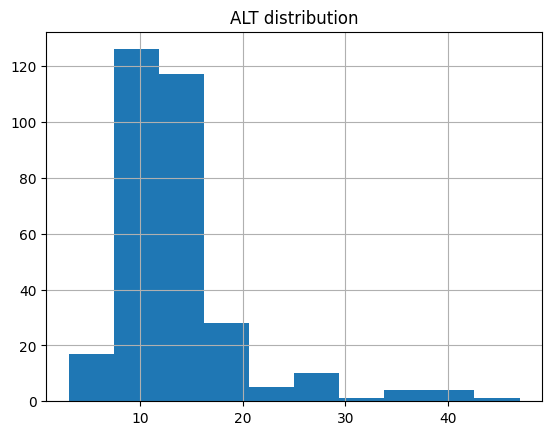

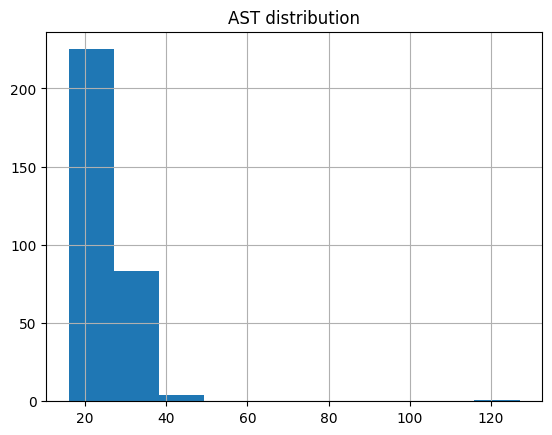

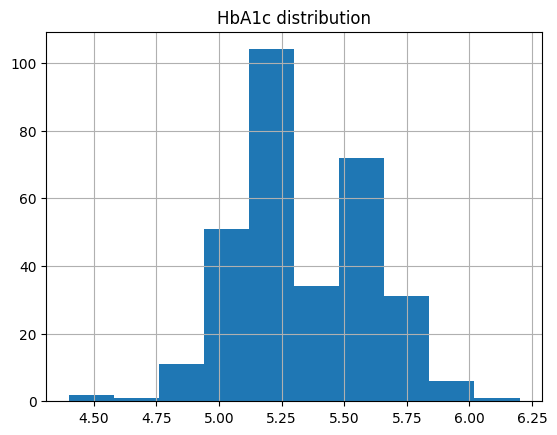

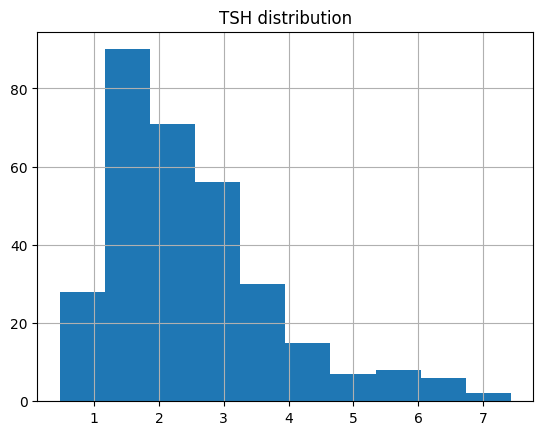

['ALT_hist.png', 'AST_hist.png', 'HbA1c_hist.png', 'TSH_hist.png']

In [9]:
df = pd.read_excel(INPUT_FILE, sheet_name=0, engine="openpyxl")
df_with_flags = build_flags(df)

generate_plots(df_with_flags.select_dtypes(include=['number']))

In [8]:
# ===============================
# ✅ SAVE REPORT
# ===============================
def save_report(df, desc, corr, outliers, plots):
    
    make_pdf("output/어린이코호트_Report.pdf",
         "Cohort Auto Report",
         desc, outliers, plots)

    log_chat("Save analysis report", "Copilot")
   
    with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='RawData', index=False)
        flags = build_flags(df)
        flags.to_excel(writer, sheet_name='Flags', index=False)
        desc.to_excel(writer, sheet_name='SummaryStats')
        corr.to_excel(writer, sheet_name='Correlation')
        outliers.to_excel(writer, sheet_name='Outliers')

In [9]:
# ===============================
# ✅ MAIN PIPELINE
# ===============================
def main():
    print("🚀 Analysis started...")

    log_chat("User started analysis.py", "User")

    df = load_data()
    desc, corr, num_df = basic_analysis(df)
    outliers = detect_outliers(num_df)
    plots = generate_plots(num_df)

    save_report(df, desc, corr, outliers, plots)

    log_chat("Analysis completed successfully", "Copilot")

    print("✅ Done!")
    print(f"📁 Report saved: {OUTPUT_FILE}")
    print(f"📊 Plots generated: {plots}")


# ===============================
# ✅ RUN
# ===============================
if __name__ == "__main__":
    main()

🚀 Analysis started...
✅ Done!
📁 Report saved: C:\Users\user2\Desktop\Machine-Learning-Exercise\ML_Projects\cohort_project\어린이코호트_자동분석리포트.xlsx
📊 Plots generated: ['ALT_hist.png', 'AST_hist.png', 'HbA1c_hist.png', 'TSH_hist.png']
